In [49]:
from pyfiles.ftsteane import *
from HPC.Upload.classes import *
from random import choices
import math
import cmath
import itertools

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.sans-serif": "Helvetica",
})

In [50]:
x = np.linspace(0.001, 0.004, 5)
y, y_qec = [], []
layers = 10
shots = 10000
bias = 0
for i in x:
    #dustin_qec = RepCode_z(3,1)
    dustin_qec = RotSurf9q(1,0)
    dustin_qec.err = True
    dustin_qec.postselection = True
    for k in range(layers):
        dustin_qec.id(0)
        # if k == 5:
        #     dustin_qec.qec(0)
        # if k == 10:
        #     dustin_qec.qec(0)
        if k != 0 and (k+1)%6 == 0:
             dustin_qec.qec(0)
            #  dustin_qec.qec(0)
    # dustin_qec.qec(0)
    dustin_qec.readout(0, shots, i)


    # phys = QuantumCircuit(1)
    # for k in range(layers):
    #     phys.h(0)
    #     phys.z(0)
    # phys.measure_all()
    # p_error = pauli_error([["X",i/2],["I",1-i],["Z",i/2]])
    # noise_model = NoiseModel()
    # noise_model.add_all_qubit_quantum_error(p_error, ["h","id","s","sdg","t","tdg","x","z"])  # Apply to single-qubit gates
    # sim = AerSimulator()
    # job = sim.run(phys, shots=shots, noise_model=noise_model)
    # result = job.result()
    # counts = result.get_counts()
    # bitstring = list(counts.keys())
    # bitstring = [i.replace(" ","") for i in bitstring]
    # hmm = list(counts.values())
    # correct = 0
    # for i in range(len(bitstring)):
    #     if bitstring[i] == "0":
    #         correct += hmm[i]
    # y.append(1-correct/shots)
    y_qec.append(1-dustin_qec.zeros/(dustin_qec.zeros+dustin_qec.ones))

In [51]:
print("Zeros: ", dustin_qec.zeros)
print("Ones: ", dustin_qec.ones)
print("Preselection: ", dustin_qec.preselected)
print("Postselection: ", dustin_qec.post)

Zeros:  0.9016
Ones:  0.0045
Preselection:  0
Postselection:  0.0939


[0.00010256410256404003, 0.0010432968179446833, 0.0018018018018017834, 0.0029038502903850905, 0.004966339256152641]


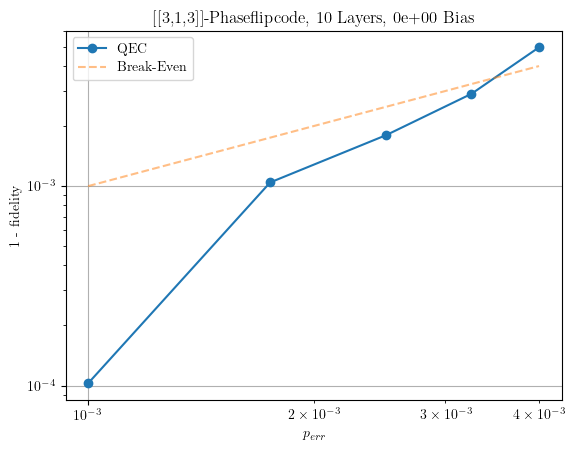

In [52]:
# print(y)
print(y_qec)

y_even = x.copy()
# plt.plot(x,y,marker="x",label="No QEC")
plt.plot(x,y_qec,marker="o",label="QEC")
plt.plot(x,y_even,linestyle="--",label="Break-Even",alpha=0.5)
plt.grid()
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"1 - fidelity")
plt.xlabel(r"$p_{err}$")
plt.title("[[3,1,3]]-Phaseflipcode, {} Layers, {:.0e} Bias".format(layers, bias))
plt.show()

In [127]:
dustin = RotSurf9q(1,0)

gates(dustin.qc)

dustin.qec(0)

gates(dustin.qc)

Amount of gates in this circuit:  12
Amount of gates in this circuit:  44
